In [15]:
import numpy as np
import math 
import matplotlib.pyplot as plt
from scipy import special
from joblib import Parallel, delayed

In [16]:
%matplotlib inline

### True Underlying Environment

In [17]:
def set_environment(n, arms, mu_a, tau_a, sigma_a, T, env_seed=0):
    mu_a = np.asarray(mu_a, dtype=float)
    tau_a = np.asarray(tau_a, dtype=float)
    sigma_a = np.asarray(sigma_a, dtype=float)

    env_rng = np.random.default_rng(env_seed)
    theta = env_rng.normal(loc=mu_a, scale=tau_a, size=(n, arms))

    return theta, sigma_a

### Learning Algorithms

#### Pooled epsilon greedy algorithm

In [18]:
def pooled_epsilon_greedy(times, participants, n_arms, theta, sigma_arm, rng, eps=0.1):
    sigma_arm = np.asarray(sigma_arm, dtype=float)

    Q_new = np.zeros(n_arms, dtype=float)
    N_new = np.zeros(n_arms, dtype=int)

    actions_new = np.zeros((participants, times), dtype=int)
    rewards_new = np.zeros((participants, times), dtype=float)

    for t in range(times):
        if rng.random() < eps:
            a = int(rng.integers(0, n_arms))
        else:
            best = np.flatnonzero(Q_new == Q_new.max())
            a = int(rng.choice(best))

        r = rng.normal(loc=theta[:, a], scale=sigma_arm[a], size=participants)

        actions_new[:, t] = a
        rewards_new[:, t] = r

        N_new[a] += participants
        Q_new[a] += (r.mean() - Q_new[a]) * (participants / N_new[a])

    return Q_new, N_new, actions_new, rewards_new

#### Thompson Sampling (Unpooled) 

In [19]:
def normal_cdf(z):
    # accept scalars or arrays; use scipy.special.erf for vectorised operation
    z = np.asarray(z, dtype=float)
    return 0.5 * (1.0 + special.erf(z / np.sqrt(2.0)))

In [20]:
def profile_ll_and_mu(x, s2, tau2):
    w = 1.0 / (s2 + tau2)
    mu = np.sum(w * x) / np.sum(w)
    ll = -0.5 * np.sum(np.log(s2 + tau2) + (x - mu) ** 2 * w)
    return ll, mu

In [21]:
def fit_mu_tau2(x, s2, grid=None):
    x = np.asarray(x, float)
    s2 = np.asarray(s2, float)
    if grid is None:
        base = float(np.var(x)) + float(np.mean(s2))
        hi = max(1e-6, 10.0 * base)
        grid = np.logspace(-8, np.log10(hi), 30)  # reduced from 120 for speed

    best_tau2 = 0.0
    best_ll, best_mu = profile_ll_and_mu(x, s2, 0.0)
    for tau2 in grid:
        ll, mu = profile_ll_and_mu(x, s2, tau2)
        if ll > best_ll:
            best_ll, best_mu, best_tau2 = ll, mu, tau2
    return best_mu, best_tau2

In [22]:
def thompson_sampling(times, participants, n_arms, theta, sigma_r, rng, mu0, tau0):
    sigma_r = np.asarray(sigma_r, float)
    mu0  = np.asarray(mu0, float)
    tau0 = np.asarray(tau0, float)

    N = np.zeros((participants, n_arms), int)
    S = np.zeros((participants, n_arms), float)
    actions = np.empty((participants, times), int)
    rewards = np.empty((participants, times), float)

    sig2_arr = (float(sigma_r) ** 2
                if sigma_r.size == 1 else sigma_r.astype(float) ** 2)

    prec_prior = 1.0 / (tau0 ** 2)

    for t in range(times):
        # posterior parameters for every (i,a) in one shot
        precision_data = N / sig2_arr
        post_var = 1.0 / (precision_data + prec_prior)            # (p, a)
        post_mean = post_var * (mu0 / (tau0 ** 2) + S / sig2_arr)  # broadcasting

        # replace rows with priors where N == 0
        mask = (N == 0)
        # np.where handles broadcasting correctly
        post_mean = np.where(mask, mu0[np.newaxis, :], post_mean)
        post_var  = np.where(mask, (tau0 ** 2)[np.newaxis, :], post_var)

        sampled = rng.normal(loc=post_mean, scale=np.sqrt(post_var))
        a_star = np.argmax(sampled, axis=1)                      # (participants,)

        # draw rewards for all agents in one go
        locs = theta[np.arange(participants), a_star]
        sigs = (float(sigma_r) if sigma_r.size == 1
                else sigma_r[a_star])
        r = rng.normal(loc=locs, scale=sigs)

        actions[:, t] = a_star
        rewards[:, t] = r
        N[np.arange(participants), a_star] += 1
        S[np.arange(participants), a_star] += r

    return N, S, actions, rewards

#### Thompson Sampling (Pooled)

In [23]:
# pooled Thompson already vectorised w.r.t. participants, but we can
# eliminate the per‑arm for‑loop
def pooled_thompson_sampling(times, participants, n_arms, theta, sigma_r, rng, mu0, tau0):
    sigma_r = np.asarray(sigma_r, float)
    mu0  = np.asarray(mu0, float)
    tau0 = np.asarray(tau0, float)

    N = np.zeros(n_arms, int)
    S = np.zeros(n_arms, float)
    actions = np.empty((participants, times), int)
    rewards = np.empty((participants, times), float)

    sig2_arr = (float(sigma_r) ** 2
                if sigma_r.size == 1 else sigma_r ** 2)
    prec_prior = 1.0 / (tau0 ** 2)

    for t in range(times):
        precision_data = N / sig2_arr
        post_var = 1.0 / (precision_data + prec_prior)
        post_mean = post_var * (mu0 / (tau0 ** 2) + S / sig2_arr)

        sampled = rng.normal(loc=post_mean, scale=np.sqrt(post_var))
        a_star = int(np.argmax(sampled))

        r = rng.normal(loc=theta[:, a_star],
                       scale=(float(sigma_r) if sigma_r.size == 1
                              else sigma_r[a_star]),
                       size=participants)

        actions[:, t] = a_star
        rewards[:, t] = r
        N[a_star] += participants
        S[a_star] += r.sum()

    return N, S, actions, rewards

#### Empirical Bayes — Nora

Empirical Bayes
1. Simple Bayesian learning algorithm
2. Empirical Bayes decision-making

In [24]:
# empirical‑Bayes learner with helpers factored out
def learning_empirical_bayes(times, participants, n_arms, theta,
                             sigma_arm, rng, mu0, tau0,
                             grid=None):
    sigma_arm = np.asarray(sigma_arm, float)
    mu0  = np.asarray(mu0, float)
    tau0 = np.asarray(tau0, float)

    m = np.broadcast_to(mu0, (participants, n_arms)).copy()
    v = np.broadcast_to(tau0**2, (participants, n_arms)).copy()

    N = np.zeros((participants, n_arms), int)
    actions = np.empty((participants, times), int)
    rewards = np.empty((participants, times), float)

    for t in range(times):
        mu_hat = np.empty(n_arms)
        tau2_hat = np.empty(n_arms)
        for a in range(n_arms):
            mu_hat[a], tau2_hat[a] = fit_mu_tau2(m[:, a], v[:, a], grid)

        # EB shrinkage for all participants/arms at once
        lam = np.where(tau2_hat > 0,
                       tau2_hat / (tau2_hat + v),
                       1.0)
        m_eb = lam * m + (1.0 - lam) * mu_hat
        v_eb = np.where(tau2_hat > 0,
                        1.0 / (1.0 / v + 1.0 / tau2_hat),
                        0.0)

        if n_arms == 2:
            diff = m_eb[:, 1] - m_eb[:, 0]
            var_diff = v_eb[:, 1] + v_eb[:, 0]
            p1 = normal_cdf(diff / np.sqrt(np.maximum(var_diff, 1e-20)))
            a_sel = (rng.random(participants) < p1).astype(int)
        else:
            sample = rng.normal(loc=m_eb, scale=np.sqrt(np.maximum(v_eb, 0.0)))
            a_sel = np.argmax(sample, axis=1)

        locs = theta[np.arange(participants), a_sel]
        sigs = sigma_arm[a_sel]
        r = rng.normal(loc=locs, scale=sigs)

        actions[:, t] = a_sel
        rewards[:, t] = r
        N[np.arange(participants), a_sel] += 1

        sig2 = sigma_arm[a_sel] ** 2
        prec = 1.0 / v[np.arange(participants), a_sel] + 1.0 / sig2
        v_new = 1.0 / prec
        m_new = v_new * (m[np.arange(participants), a_sel] / v[np.arange(participants), a_sel]
                         + r / sig2)

        m[np.arange(participants), a_sel] = m_new
        v[np.arange(participants), a_sel] = v_new

    return m, v, N, actions, rewards

### Simulations

#### Functions

In [25]:
def evaluate(theta, sigma_a, T, eps, mu0, tau0, seed=123):
    n, arms = theta.shape
    mu0  = np.asarray(mu0, dtype=float)
    tau0 = np.asarray(tau0, dtype=float)

    # no greedy algorithm used any more
    rng_ts       = np.random.default_rng(seed + 2)
    rng_pool_ts  = np.random.default_rng(seed + 3)
    rng_eb       = np.random.default_rng(seed + 4)

    N_ts, S_ts, actions_ts, rewards_ts = thompson_sampling(
        T, n, arms, theta, sigma_a, rng_ts, mu0=mu0, tau0=tau0
    )

    N_pts, S_pts, actions_pts, rewards_pts = pooled_thompson_sampling(
        T, n, arms, theta, sigma_a, rng_pool_ts, mu0=mu0, tau0=tau0
    )

    m_eb, v_eb, N_eb, actions_eb, rewards_eb = learning_empirical_bayes(
        T, n, arms, theta, sigma_a, rng_eb, mu0=mu0, tau0=tau0
    )

    return {
        "actions_thompson": actions_ts,
        "actions_pooled_thompson": actions_pts,
        "actions_eb": actions_eb,
        "regret_thompson": cumulative_regret(theta, actions_ts),               # (n, T)
        "regret_pooled_thompson": cumulative_regret(theta, actions_pts),       # (n, T)
        "regret_eb": cumulative_regret(theta, actions_eb),                     # (n, T)
        "rewards_thompson": rewards_ts,
        "rewards_pooled_thompson": rewards_pts,
        "rewards_eb": rewards_eb,
        "N_ts": N_ts,
        "S_ts": S_ts,
        "N_pooled_ts": N_pts,
        "S_pooled_ts": S_pts,
        "m_eb": m_eb,
        "v_eb": v_eb,
        "N_eb": N_eb,
    }


In [26]:
def plot(ns, mus, taus, T, sigma_a, n_runs=50, env_seed=0, eps=0.1,
         mu0=None, tau0=None, show_prior_in_title=True, note=None):
    # colour map now only contains algorithms we actually plot
    PASTEL = {
        "thompson": "#FFB482",          # unpooled TS
        "pooled_thompson": "#9C88B9",   # pooled TS
        "eb": "#8DE5A1",                # empirical Bayes
    }

    def fmt_vec(x):
        x = np.asarray(x, dtype=float)
        return "[" + ", ".join(f"{v:.2f}" for v in x) + "]"

    n_rows = len(taus)
    n_cols = len(mus)

    for n_val in ns:
        fig, axs = plt.subplots(
            n_rows, n_cols,
            figsize=(3.2 * n_cols, 2.4 * n_rows),
            sharex=True, sharey=False
        )

        if n_rows == 1 and n_cols == 1:
            axs = np.array([[axs]])
        elif n_rows == 1:
            axs = np.array([axs])
        elif n_cols == 1:
            axs = np.array([[ax] for ax in axs])

        for i, tau_val in enumerate(taus):
            for j, mu_val in enumerate(mus):
                mu_env  = [0.0, float(mu_val)]
                tau_env = [float(tau_val), float(tau_val)]

                theta, sigma_env = set_environment(
                    n=n_val, arms=2, mu_a=mu_env, tau_a=tau_env,
                    sigma_a=sigma_a, T=T, env_seed=env_seed
                )

                if callable(mu0):
                    mu0_use = np.asarray(mu0(mu_env, tau_env), dtype=float)
                else:
                    mu0_use = np.asarray(mu0, dtype=float)

                if callable(tau0):
                    tau0_use = np.asarray(tau0(mu_env, tau_env), dtype=float)
                else:
                    tau0_use = np.asarray(tau0, dtype=float)

                # collect per-run regret curves (mean across participants)
                reg_ts_list  = []
                reg_pts_list = []
                reg_eb_list  = []

                for r in range(n_runs):
                    out = evaluate(
                        theta=theta,
                        sigma_a=sigma_env,
                        T=T,
                        eps=eps,
                        mu0=mu0_use,
                        tau0=tau0_use,
                        seed=r
                    )
                    reg_ts_list.append(out["regret_thompson"])             # (n, T)
                    reg_pts_list.append(out["regret_pooled_thompson"])     # (n, T)
                    reg_eb_list.append(out["regret_eb"])                   # (n, T)

                # ---- per-run means across participants ----
                reg_ts_runs  = np.stack(reg_ts_list, axis=0).mean(axis=1)
                reg_pts_runs = np.stack(reg_pts_list, axis=0).mean(axis=1)
                reg_eb_runs  = np.stack(reg_eb_list, axis=0).mean(axis=1)

                # ---- overall mean curves (length T) ----
                reg_ts  = reg_ts_runs.mean(axis=0)
                reg_pts = reg_pts_runs.mean(axis=0)
                reg_eb  = reg_eb_runs.mean(axis=0)

                # ---- CI shading (99% interval for more visible bands) ----
                Z = 2.58
                t = np.arange(T)
                ts_se  = reg_ts_runs.std(axis=0, ddof=1) / np.sqrt(n_runs)
                pts_se = reg_pts_runs.std(axis=0, ddof=1) / np.sqrt(n_runs)
                eb_se  = reg_eb_runs.std(axis=0, ddof=1) / np.sqrt(n_runs)
                ts_lo,  ts_hi  = reg_ts  - Z * ts_se,  reg_ts  + Z * ts_se
                pts_lo, pts_hi = reg_pts - Z * pts_se, reg_pts + Z * pts_se
                eb_lo,  eb_hi  = reg_eb  - Z * eb_se,  reg_eb  + Z * eb_se

                # choose winner (ignore greedy entirely)
                final_vals = {
                    "Unpooled Thompson": reg_ts[-1],
                    "Pooled Thompson": reg_pts[-1],
                    "EB": reg_eb[-1],
                }
                best_alg = min(final_vals, key=final_vals.get)

                ax = axs[i, j]

                ax.fill_between(t, ts_lo,  ts_hi,  color=PASTEL["thompson"],        alpha=0.30, linewidth=0)
                ax.fill_between(t, pts_lo, pts_hi, color=PASTEL["pooled_thompson"], alpha=0.30, linewidth=0)
                ax.fill_between(t, eb_lo,  eb_hi,  color=PASTEL["eb"],              alpha=0.30, linewidth=0)

                ax.plot(t, reg_ts,  color=PASTEL["thompson"],        linewidth=1.4)
                ax.plot(t, reg_pts, color=PASTEL["pooled_thompson"], linewidth=1.4)
                ax.plot(t, reg_eb,  color=PASTEL["eb"],              linewidth=1.4)

                title = f"μ₂={mu_val}, τ={tau_val}"
                title += f"\nBest: {best_alg}"
                ax.set_title(title, fontsize=9)

                ax.tick_params(axis="both", labelsize=7)
                if i == n_rows - 1:
                    ax.set_xlabel("t", fontsize=8)
                if j == 0:
                    ax.set_ylabel("Avg cum. regret", fontsize=8)

        handles, _ = axs[0, 0].get_legend_handles_labels()
        fig.legend(handles, ["Unpooled Thompson", "Pooled Thompson", "EB"],
                   loc="upper right", fontsize=8)

        mu0_vec   = fmt_vec(mu0_use)
        tau0_vec  = fmt_vec(tau0_use)
        sigma_vec = fmt_vec(sigma_a)

        main_title = (
            f"n = {n_val}, runs = {n_runs}\n"
            f"Within-person σ = {sigma_vec}\n"
            f"μ0 = {mu0_vec}, τ0 = {tau0_vec}"
        )

        if note is not None:
            main_title += f"\n{note}"

        fig.suptitle(main_title, fontsize=11)
        fig.tight_layout(rect=[0, 0, 0.95, 0.95])
        plt.show()


#### Trials - Varying Mean

In [ ]:
plot(
    ns=[50],
    mus=[0, 3],
    taus=[0.5, 1.0, 5.0],          # baseline tau grid
    T=200, 
    sigma_a=[0.01, 0.01],           # LOW within-person variance
    n_runs=100,
    env_seed=0,
    eps=0.1,
    mu0=[0.0, 0],               # centered in interval
    tau0=[0.1, 0.1],              # moderately informative
    note="Low btwn person var, low within person var, good priors"
)

/var/folders/5g/p9xms7rx5sl5n3205_lhj8lw0000gp/T/ipykernel_30387/625489017.py:28: RuntimeWarning: divide by zero encountered in divide
  1.0 / (1.0 / v + 1.0 / tau2_hat),


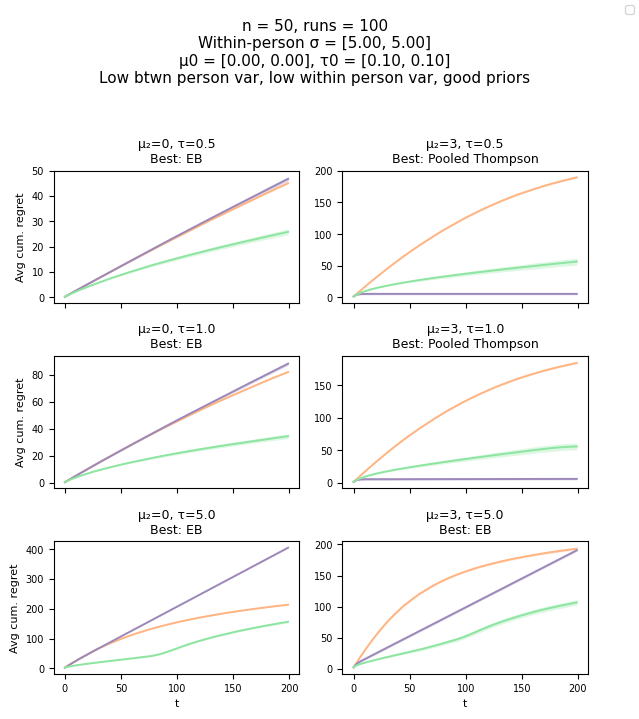

In [30]:
plot(
    ns=[50],
    mus=[0, 3],
    taus=[0.5, 1.0, 5.0],          # baseline tau grid
    T=200, 
    sigma_a=[5, 5],           # LOW within-person variance
    n_runs=100,
    env_seed=0,
    eps=0.1,
    mu0=[0.0, 0],               # centered in interval
    tau0=[0.1, 0.1],              # moderately informative
    note="Low btwn person var, low within person var, good priors"
)

- **Unpooled Thompson** = soft orange
- **Pooled Thompson** = soft purple
- **EB** = light green